In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import hopsworks
from dotenv import load_dotenv

load_dotenv()
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

project = hopsworks.login(
    host=os.getenv("HOPSWORKS_HOST"),
    project=os.getenv("HOPSWORKS_PROJECT"),
    api_key_value=os.getenv("HOPSWORKS_API_KEY"),
    engine="python",
)
fs = project.get_feature_store()

2026-08-13 23:19:50,600 INFO: Initializing external client
2026-08-13 23:19:50,616 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-08-13 23:19:57,070 INFO: Python Engine initialized.



Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/41159


In [3]:
raw_fg = fs.get_feature_group(name="aqi_raw_hourly", version=1)
hourly_df = raw_fg.read()
hourly_df["time"] = pd.to_datetime(hourly_df["time"])
hourly_df = hourly_df.sort_values("time").reset_index(drop=True)

daily_fg = fs.get_feature_group(name="aqi_daily_features", version=2)
daily_df = daily_fg.read()
daily_df["date"] = pd.to_datetime(daily_df["date"])
daily_df = daily_df.sort_values("date").reset_index(drop=True)

print(f"Hourly rows: {hourly_df.shape}")
print(f"Daily rows: {daily_df.shape}")
hourly_df.head()

Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (4.28s) 
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (1.73s) 
Hourly rows: (17655, 15)
Daily rows: (726, 46)


,time,us_aqi,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,surface_pressure,precipitation,shortwave_radiation
0,2024-08-08 00:00:00+00:00,71,22.6,71.9,192.0,11.9,3.8,40.0,27.9,82,19.6,234,1001.6,0.0,0.0
1,2024-08-08 01:00:00+00:00,71,21.8,69.4,168.0,9.1,3.4,42.0,27.9,81,20.1,237,1001.3,0.0,0.0
2,2024-08-08 02:00:00+00:00,71,21.2,65.2,150.0,7.0,3.2,44.0,27.9,81,20.3,240,1000.7,0.0,0.0
3,2024-08-08 03:00:00+00:00,71,22.5,67.8,141.0,6.1,3.3,44.0,28.0,80,20.2,248,1000.7,0.0,0.0
4,2024-08-08 04:00:00+00:00,72,21.8,61.2,137.0,5.9,3.5,43.0,27.9,81,21.3,248,1000.6,0.0,0.0


## 1. Data Quality Check — Duplicates
Verifying no duplicate timestamps exist in the hourly or daily feature groups before proceeding with analysis.

In [4]:
# cell 02b — duplicate timestamp check

print("Duplicate hourly timestamps:", hourly_df["time"].duplicated().sum())
print("Duplicate daily dates:", daily_df["date"].duplicated().sum())

Duplicate hourly timestamps: 0
Duplicate daily dates: 0


## 2. AQI Over Time

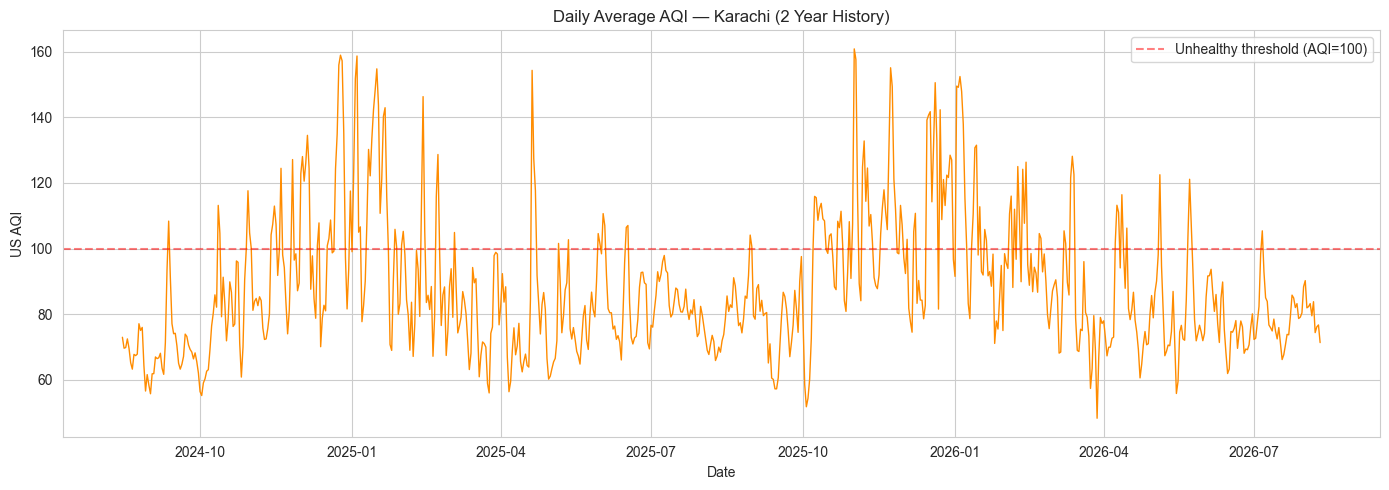

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_df["date"], daily_df["us_aqi"], linewidth=1, color="darkorange")
ax.set_title("Daily Average AQI — Karachi (2 Year History)")
ax.set_xlabel("Date")
ax.set_ylabel("US AQI")
ax.axhline(y=100, color="red", linestyle="--", alpha=0.5, label="Unhealthy threshold (AQI=100)")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Seasonal Pattern (Monthly Average)

2026-08-13 23:20:56,426 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-13 23:20:56,443 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


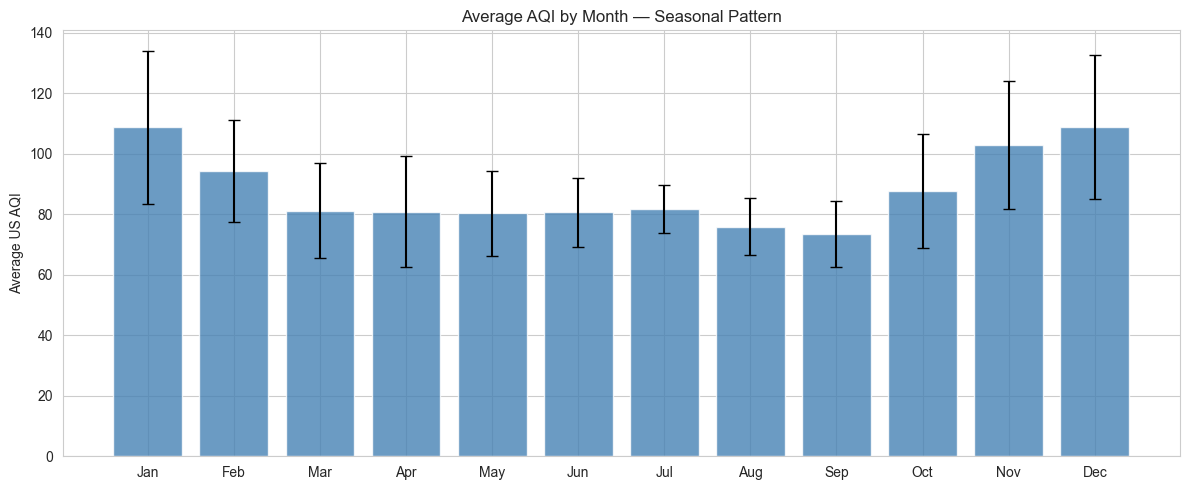

month_name       mean
       Jan 108.766801
       Feb  94.459821
       Mar  81.170699
       Apr  80.881944
       May  80.346102
       Jun  80.626389
       Jul  81.766129
       Aug  75.882902
       Sep  73.498611
       Oct  87.733199
       Nov 102.907639
       Dec 108.929435


In [6]:
monthly_avg = daily_df.groupby("month")["us_aqi"].agg(["mean", "std"]).reset_index()
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
monthly_avg["month_name"] = monthly_avg["month"].apply(lambda x: month_names[x-1])

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(monthly_avg["month_name"], monthly_avg["mean"], yerr=monthly_avg["std"], 
       capsize=4, color="steelblue", alpha=0.8)
ax.set_title("Average AQI by Month — Seasonal Pattern")
ax.set_ylabel("Average US AQI")
plt.tight_layout()
plt.show()

print(monthly_avg[["month_name", "mean"]].to_string(index=False))

## 4. Year-over-Year Consistency Check
Comparing average AQI and record counts across the two years of backfilled data to catch any collection gaps or anomalies before training.

2026-08-13 23:25:07,698 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


           mean        std  count
year                             
2024  85.800959  22.193203    139
2025  90.195091  21.672391    365
2026  86.209272  17.966609    222


2026-08-13 23:25:07,747 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


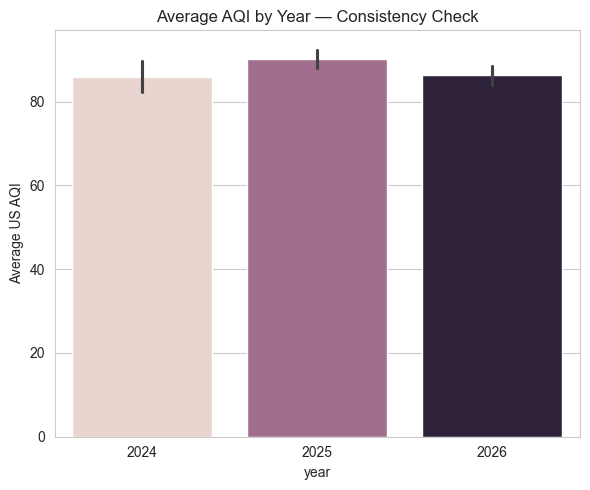

In [8]:
# cell 04b — year-over-year consistency check

daily_df["year"] = daily_df["date"].dt.year

yoy = daily_df.groupby("year")["us_aqi"].agg(["mean", "std", "count"])
print(yoy)

fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(data=daily_df, x="year", y="us_aqi", estimator="mean", 
            hue="year", legend=False, ax=ax)
ax.set_title("Average AQI by Year — Consistency Check")
ax.set_ylabel("Average US AQI")
plt.tight_layout()
plt.show()

## 5. Day-of-Week Pattern

2026-08-13 23:25:29,222 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-13 23:25:29,248 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


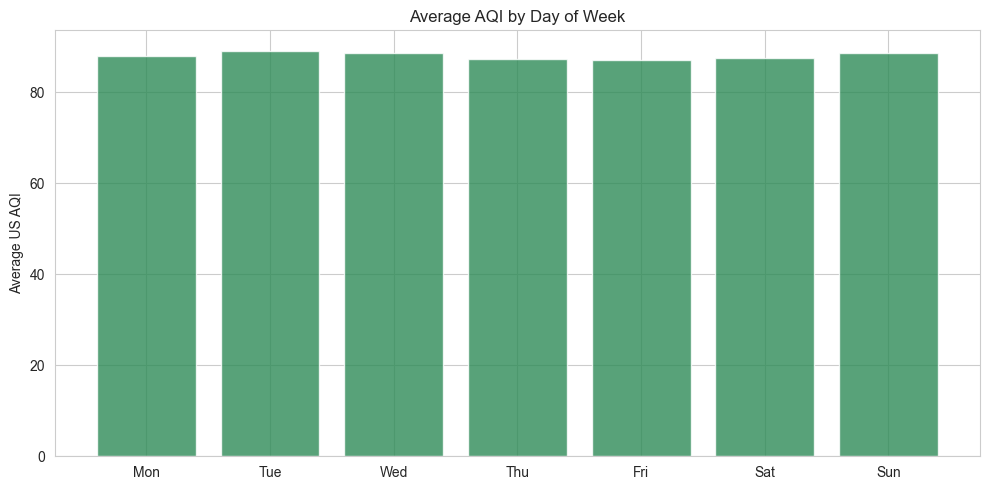

In [9]:
dow_names = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
dow_avg = daily_df.groupby("day_of_week")["us_aqi"].mean().reset_index()
dow_avg["day_name"] = dow_avg["day_of_week"].apply(lambda x: dow_names[x])

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(dow_avg["day_name"], dow_avg["us_aqi"], color="seagreen", alpha=0.8)
ax.set_title("Average AQI by Day of Week")
ax.set_ylabel("Average US AQI")
plt.tight_layout()
plt.show()

## 6. Correlation Between AQI and Weather/Pollutants

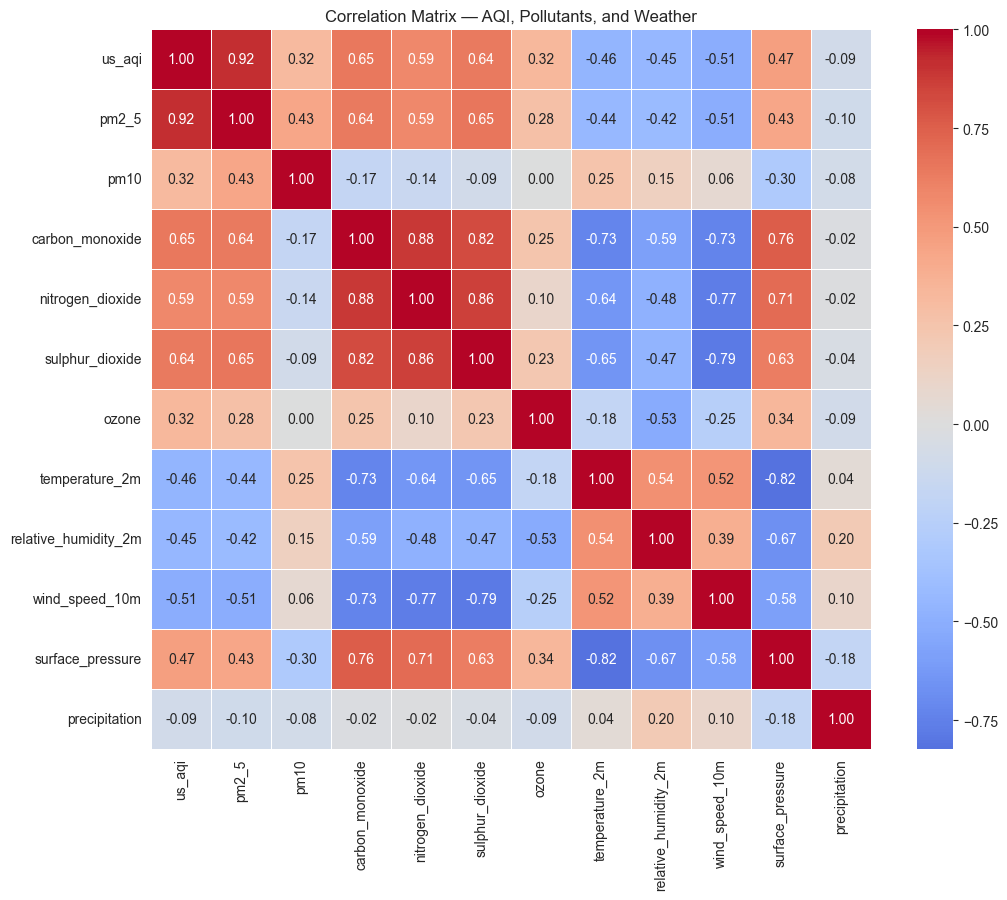


Strongest correlations with AQI:
pm2_5                   0.917890
carbon_monoxide         0.646426
sulphur_dioxide         0.642513
nitrogen_dioxide        0.586862
wind_speed_10m         -0.514958
surface_pressure        0.471716
temperature_2m         -0.460058
relative_humidity_2m   -0.448757
ozone                   0.324232
pm10                    0.316423
precipitation          -0.092072
Name: us_aqi, dtype: float64


In [10]:
corr_cols = ["us_aqi", "pm2_5", "pm10", "carbon_monoxide", "nitrogen_dioxide",
             "sulphur_dioxide", "ozone", "temperature_2m", "relative_humidity_2m",
             "wind_speed_10m", "surface_pressure", "precipitation"]

corr_matrix = daily_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix — AQI, Pollutants, and Weather")
plt.tight_layout()
plt.show()

print("\nStrongest correlations with AQI:")
print(corr_matrix["us_aqi"].drop("us_aqi").sort_values(key=abs, ascending=False))

## 7. AQI Distribution and Category Breakdown

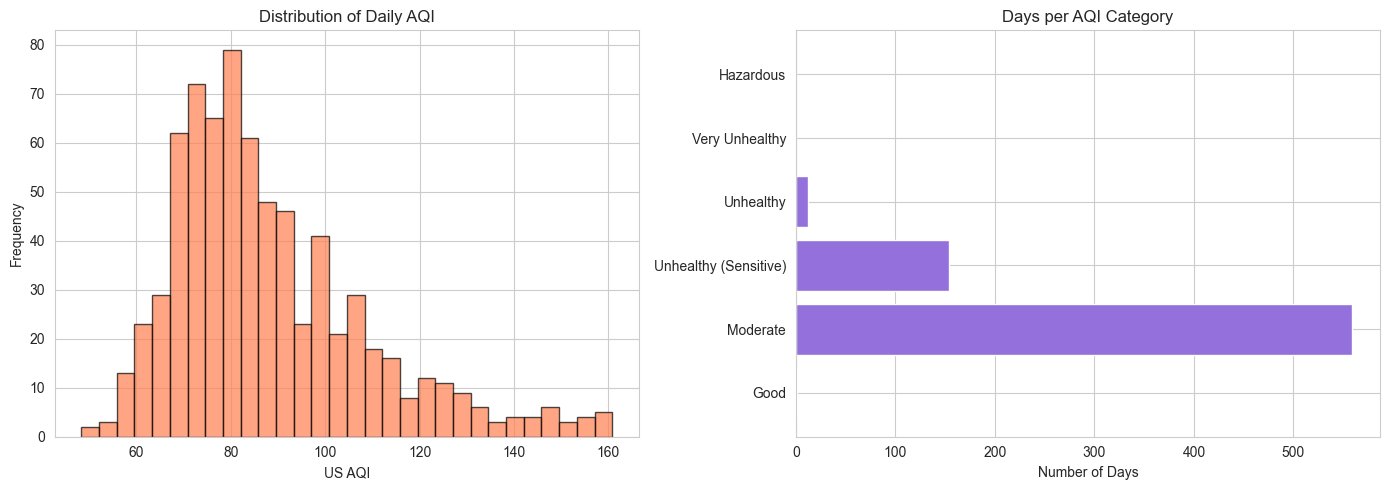

aqi_category
Good                       1.0
Moderate                 559.0
Unhealthy (Sensitive)    154.0
Unhealthy                 12.0
Very Unhealthy             0.0
Hazardous                  0.0
Name: count, dtype: float64


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(daily_df["us_aqi"], bins=30, color="coral", edgecolor="black", alpha=0.7)
axes[0].set_title("Distribution of Daily AQI")
axes[0].set_xlabel("US AQI")
axes[0].set_ylabel("Frequency")

def categorize_aqi(aqi):
    if aqi <= 50: return "Good"
    elif aqi <= 100: return "Moderate"
    elif aqi <= 150: return "Unhealthy (Sensitive)"
    elif aqi <= 200: return "Unhealthy"
    elif aqi <= 300: return "Very Unhealthy"
    else: return "Hazardous"

daily_df["aqi_category"] = daily_df["us_aqi"].apply(categorize_aqi)
category_order = ["Good", "Moderate", "Unhealthy (Sensitive)", "Unhealthy", "Very Unhealthy", "Hazardous"]
category_counts = daily_df["aqi_category"].value_counts().reindex(category_order).fillna(0)

axes[1].barh(category_counts.index, category_counts.values, color="mediumpurple")
axes[1].set_title("Days per AQI Category")
axes[1].set_xlabel("Number of Days")

plt.tight_layout()
plt.show()

print(category_counts)

## 8. Outlier Detection
Visual check for extreme AQI values, complementing the automated outlier flagging already applied in `preprocessing.py`.

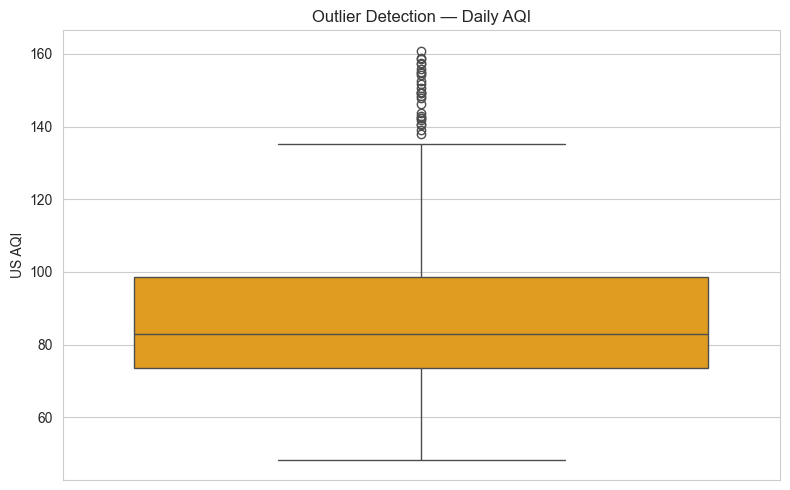

In [12]:
# cell 07b — outlier detection

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(y=daily_df["us_aqi"], color="orange", ax=ax)
ax.set_title("Outlier Detection — Daily AQI")
ax.set_ylabel("US AQI")
plt.tight_layout()
plt.show()

## 9. Wind Speed vs AQI (dispersion effect)

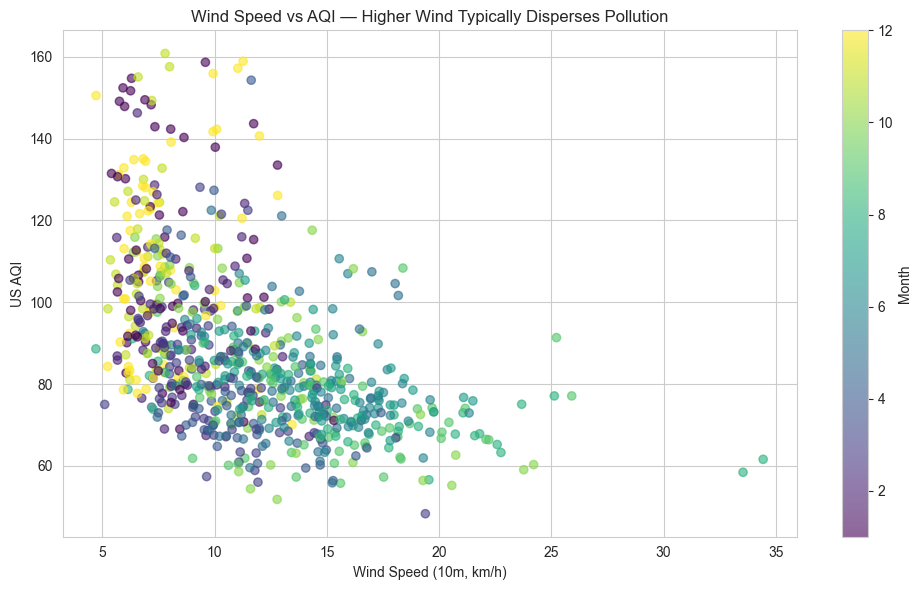

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(daily_df["wind_speed_10m"], daily_df["us_aqi"], 
                       c=daily_df["month"], cmap="viridis", alpha=0.6)
ax.set_xlabel("Wind Speed (10m, km/h)")
ax.set_ylabel("US AQI")
ax.set_title("Wind Speed vs AQI — Higher Wind Typically Disperses Pollution")
plt.colorbar(scatter, label="Month")
plt.tight_layout()
plt.show()

## 10. Summary of Key Findings

**Seasonality is the dominant driver.** AQI follows a clear annual cycle tied to winter 
temperature inversions: average AQI rises from ~75 in Aug–Sep to ~103–109 in Nov–Jan, 
with winter months also showing higher day-to-day volatility. The 2-year time series 
confirms this pattern repeats consistently across both winters, with peaks reaching 
150–160 against a summer floor of ~55–70.

**PM2.5 dominates the composite AQI score** (r=0.92), consistent with Karachi's air 
quality being driven primarily by particulate pollution rather than gaseous pollutants. 
Combustion-related gases (CO, NO2, SO2) are highly intercorrelated (r=0.82–0.88), 
reflecting shared traffic/industrial sources.

**Wind, temperature, and pressure jointly explain the seasonal pattern**: AQI correlates 
negatively with wind speed (r=-0.51) and temperature (r=-0.46), and positively with 
surface pressure (r=0.47) — the signature of winter inversions where calm, high-pressure, 
cool conditions trap pollutants near the surface.

**Karachi has no "clean air" baseline.** Of ~726 days analyzed, only 1 qualified as 
"Good" by US AQI standards; 558 were Moderate and 166 fell in Unhealthy or 
Unhealthy-for-Sensitive-Groups territory. No Hazardous or Very Unhealthy days occurred 
in this window — worth noting as a modeling caveat, since the models have not seen 
examples from those upper categories.

**Day-of-week has no meaningful effect** on AQI (86–89 across all seven days), unlike 
month — confirming that pollution drivers here are seasonal/meteorological rather than 
tied to a weekly human-activity cycle.

**Data quality:** No duplicate timestamps in hourly or daily data. Year-over-year means 
are stable (85.8–90.2 across 2024–2026), with 2024 and 2026 being partial years due to 
the backfill window.